In [3]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [4]:
conn = sqlite3.connect("online_retail_new.db")

In [5]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,online_retail
1,online_retail_clean
2,online_retail_month_key
3,online_retail_monthly_ready
4,customer_summary
5,monthly_kpi_panel
6,product_summary


# Online Retail SQL + Business Analysis Project

## 1. Introduction

This project analyzes the UCI Online Retail dataset using SQL for data preparation and pandas/Python for validation, visualization, and business interpretation. The goal is to move beyond basic KPI reporting and identify meaningful business patterns in customer behavior, product performance, and monthly sales trends.

The dataset is at the line-item level, meaning each row represents one product line within an invoice rather than one complete order. Because of this, order-level and customer-level metrics must be carefully aggregated before analysis.

The main business questions in this project are:
- How dependent is revenue on repeat and high-value customers?
- Are product revenues concentrated in a small number of items, or spread more broadly?
- Are monthly revenue changes driven more by order volume and customer activity, or by AOV?

## 2. Data Preparation

In [6]:
clean_df = pd.read_sql("SELECT * FROM online_retail_clean", conn)
customer_summary = pd.read_sql("SELECT * FROM customer_summary", conn)
product_summary = pd.read_sql("SELECT * FROM product_summary", conn)
monthly_kpi = pd.read_sql("SELECT * FROM monthly_kpi_panel", conn)

In [7]:
print("clean_df:", clean_df.shape)
print("customer_summary:", customer_summary.shape)
print("product_summary:", product_summary.shape)
print("monthly_kpi:", monthly_kpi.shape)

clean_df: (397884, 9)
customer_summary: (4338, 6)
product_summary: (3665, 5)
monthly_kpi: (13, 5)


## 3. Customer Analysis
This section examines how revenue is distributed across customers. Instead of stopping at a simple top-customer ranking, the analysis first aggregates transaction-level data to the customer level and then groups customers into revenue-based segments. The goal is to understand whether business revenue is broadly distributed across the customer base or concentrated in a smaller group of high-value customers.

To create customer segments, customers were first ranked by total revenue contribution. Based on this revenue rank, the top 10% were labeled as high-value, the next 40% as mid-value, and the bottom 50% as low-value. The assigned `customer_segment` column shown below was created from this rule rather than coming from the original dataset.

The table below shows the customer-level summary used for segmentation. Each customer is aggregated into one row with total revenue, order count, customer-level AOV, revenue rank, and the assigned customer segment.

In [8]:
customer_summary[[
    "CustomerID",
    "customer_revenue",
    "number_of_orders",
    "customer_AOV",
    "revenue_rank",
    "customer_segment"
]].head(10)

,CustomerID,customer_revenue,number_of_orders,customer_AOV,revenue_rank,customer_segment
0,14646,280206.02,73,3838.438630,1,high-value
1,18102,259657.30,60,4327.621667,2,high-value
2,17450,194550.79,46,4229.365000,3,high-value
3,16446,168472.50,2,84236.250000,4,high-value
4,14911,143825.06,201,715.547562,5,high-value
5,12415,124914.53,21,5948.310952,6,high-value
6,14156,117379.63,55,2134.175091,7,high-value
7,17511,91062.38,31,2937.496129,8,high-value
8,16029,81024.84,63,1286.108571,9,high-value
9,12346,77183.60,1,77183.600000,10,high-value


The table below summarizes the customer segments created from the customer-level summary. It shows both the size of each segment and how much revenue each segment contributes.

In [9]:
customer_segment_summary = pd.read_sql("""
SELECT
    customer_segment,
    COUNT(*) AS num_customer,
    100.0 * COUNT(*) / SUM(COUNT(*)) OVER () AS customer_share_percent,
    SUM(customer_revenue) AS segment_revenue,
    100.0 * SUM(customer_revenue) / SUM(SUM(customer_revenue)) OVER () AS revenue_share_percent
FROM customer_summary
GROUP BY customer_segment
ORDER BY CASE
    WHEN customer_segment = 'high-value' THEN 1
    WHEN customer_segment = 'mid-value' THEN 2
    ELSE 3
END
""", conn)

customer_segment_summary

,customer_segment,num_customer,customer_share_percent,segment_revenue,revenue_share_percent
0,high-value,434,10.00461,5469382.460,61.375066
1,mid-value,1735,39.99539,2744058.502,30.792648
2,low-value,2169,50.00000,697966.942,7.832286


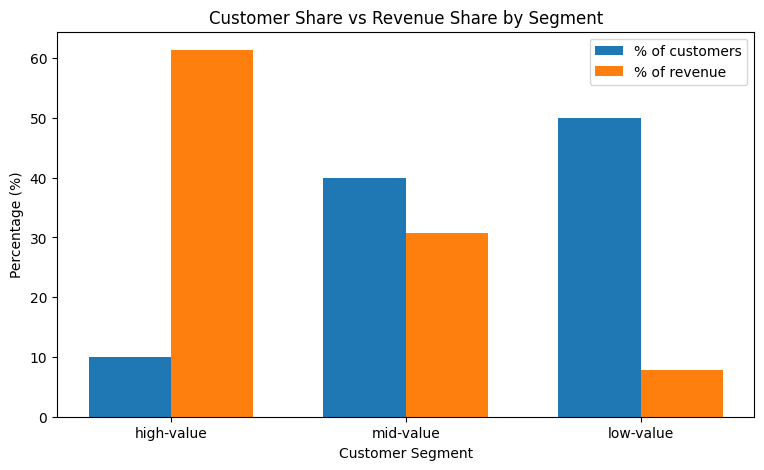

In [10]:
import numpy as np

x = np.arange(len(customer_segment_summary["customer_segment"]))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, customer_segment_summary["customer_share_percent"], width, label="% of customers")
plt.bar(x + width/2, customer_segment_summary["revenue_share_percent"], width, label="% of revenue")

plt.xticks(x, customer_segment_summary["customer_segment"])
plt.title("Customer Share vs Revenue Share by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Percentage (%)")
plt.legend()
plt.show()

The segmentation results show that customer revenue is highly concentrated. High-value customers account for only 10% of the customer base but contribute more than 60% of total revenue, while the bottom 50% contribute less than 10%. This shows that business revenue is not broadly distributed across customers, but instead depends heavily on a relatively small high-value segment.

This result also has an important retention implication. Combined with the earlier repeat-customer finding from the SQL analysis, it suggests that revenue performance is driven more by retaining and expanding high-value repeat customers than by relying mainly on one-time customer acquisition.

In [11]:
top10_customer_share = pd.read_sql("""
SELECT
    top_10_revenue,
    total_revenue,
    100.0 * top_10_revenue / total_revenue AS top_10_customer_revenue_share_percent
FROM
(
    SELECT
        SUM(customer_revenue) AS top_10_revenue,
        (SELECT SUM(Revenue) FROM online_retail_clean) AS total_revenue
    FROM
    (
        SELECT
            CustomerID,
            SUM(Revenue) AS customer_revenue
        FROM online_retail_clean
        GROUP BY CustomerID
        ORDER BY customer_revenue DESC
        LIMIT 10
    ) AS top_customers
) AS summary
""", conn)

top10_customer_share["top_10_customer_revenue_share_percent"] = top10_customer_share["top_10_customer_revenue_share_percent"].round(2)
top10_customer_share

,top_10_revenue,total_revenue,top_10_customer_revenue_share_percent
0,1538276.65,8911407.904,17.26


As supporting evidence, the top 10 customers alone contribute about 17.2% of total revenue. This is consistent with the broader segmentation result, which shows that revenue is concentrated in a relatively small group of customers.

## 4. Product Analysis
This section examines whether product revenue is concentrated in a small number of items or spread across a broader product mix. Instead of looking only at product revenue rankings, the analysis also considers customer reach and order reach to distinguish between broadly demanded products and concentrated bulk-purchase effects.

The table below shows the product-level summary constructed from transaction-level data. In addition to total product revenue and units sold, it also includes distinct customer count and distinct order count so that high-revenue products can be interpreted in terms of customer reach rather than revenue alone.

In [12]:
product_summary.sort_values("total_product_revenue", ascending=False).head(10)

,StockCode,total_product_revenue,total_units_sold,distinct_customers,distinct_orders
2399,23843,168469.60,80995,1,1
1288,22423,142592.95,12402,881,1703
3233,85123A,100603.50,36782,856,1978
3219,85099B,85220.78,46181,635,1600
1997,23166,81416.73,77916,138,195
3664,POST,77803.96,3120,331,1099
2593,47566,68844.33,15291,708,1379
3059,84879,56580.34,35362,678,1375
3662,M,53779.93,7173,197,253
1919,23084,51346.20,27202,450,801


The top revenue products do not all behave the same way. Some products, such as StockCode 22423 and 85123A, generate high revenue across many customers and many orders, which makes them look like broad-demand core products. In contrast, StockCode 23843 has the highest product revenue but comes from only one customer and one order, suggesting that its performance is driven by a concentrated bulk purchase rather than widespread product demand.

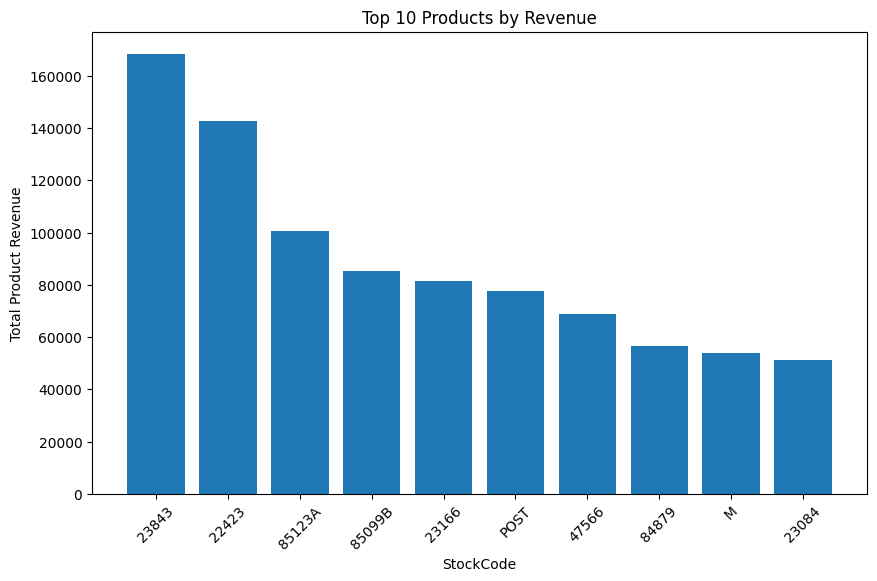

In [13]:
top10_products_revenue = product_summary.sort_values(
    "total_product_revenue", ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10_products_revenue["StockCode"].astype(str), top10_products_revenue["total_product_revenue"])
plt.title("Top 10 Products by Revenue")
plt.xlabel("StockCode")
plt.ylabel("Total Product Revenue")
plt.xticks(rotation=45)
plt.show()

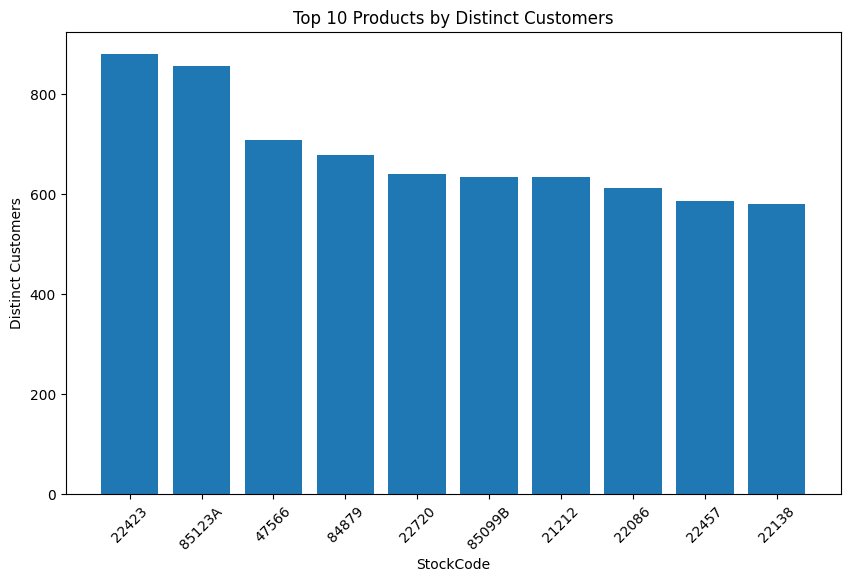

In [14]:
top10_products_customers = product_summary.sort_values(
    "distinct_customers", ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10_products_customers["StockCode"].astype(str), top10_products_customers["distinct_customers"])
plt.title("Top 10 Products by Distinct Customers")
plt.xlabel("StockCode")
plt.ylabel("Distinct Customers")
plt.xticks(rotation=45)
plt.show()

These results show that top product performance is not driven by a single mechanism. Some products, such as StockCode 22423 and 85123A, rank highly in both revenue and distinct customer reach, which suggests that they function as broad-demand core products. In contrast, StockCode 23843 generates the highest product revenue but does not appear among the top products by customer reach. Combined with the earlier product summary table, this suggests that its revenue is driven by a concentrated bulk purchase rather than widespread demand.

More broadly, this comparison suggests that product revenue is not purely a function of popularity. Some products generate high revenue because they are broadly purchased across many customers, while others are lifted by a small number of large purchases.

## 5. Monthly Trend Analysis
This section examines how monthly business performance changes over time. Rather than only plotting monthly KPIs, the goal is to understand whether revenue fluctuations are more closely associated with order volume and active customer count or with changes in AOV.

In [15]:
monthly_kpi

,invoice_month,monthly_revenue,monthly_orders,monthly_customers,monthly_AOV
0,2010-12,572713.890,1400,885,409.081350
1,2011-01,569445.040,987,741,576.945329
2,2011-02,447137.350,997,758,448.482798
3,2011-03,595500.760,1321,974,450.795428
4,2011-04,469200.361,1149,856,408.355406
5,2011-05,678594.560,1555,1056,436.395215
6,2011-06,661213.690,1393,991,474.668837
7,2011-07,600091.011,1331,949,450.857258
8,2011-08,645343.900,1280,935,504.174922
9,2011-09,952838.382,1755,1266,542.927853


To understand what drives monthly revenue changes, the analysis compares revenue with three related monthly indicators: order volume, active customer count, and AOV. Looking at these trends together makes it possible to evaluate whether revenue fluctuations are more closely associated with transaction volume and customer activity or with changes in average order value.

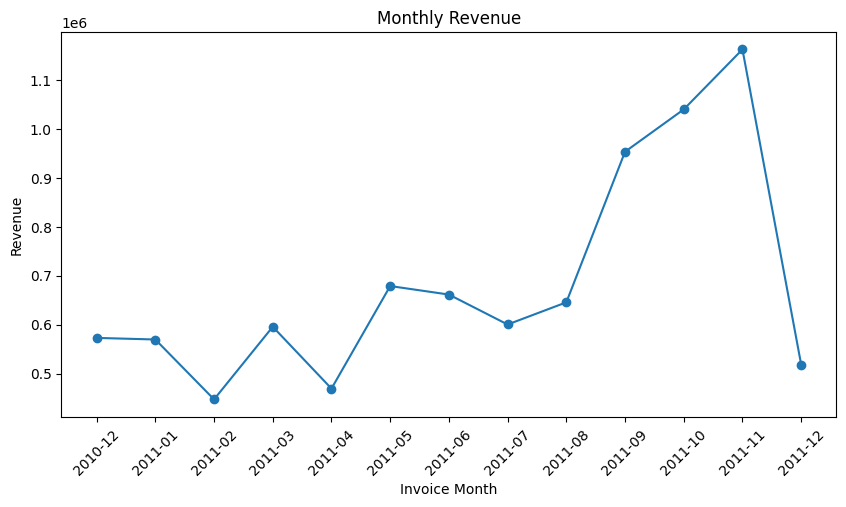

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_kpi["invoice_month"], monthly_kpi["monthly_revenue"], marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Invoice Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

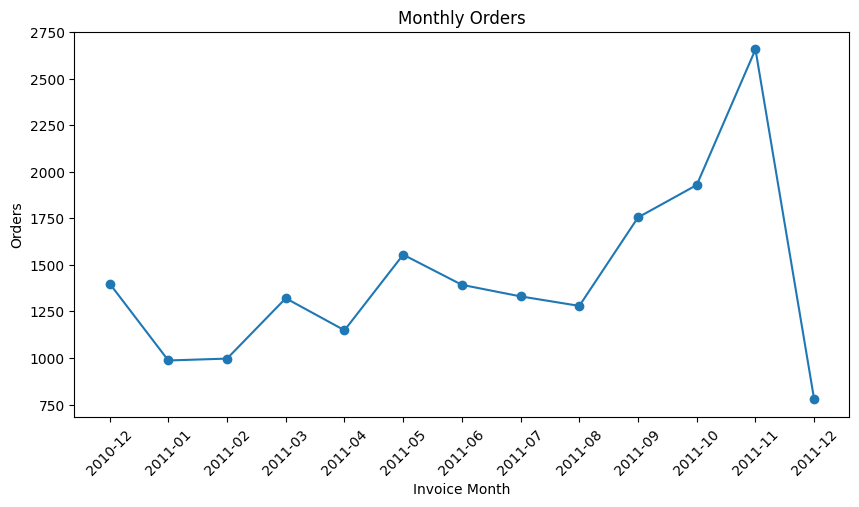

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_kpi["invoice_month"], monthly_kpi["monthly_orders"], marker="o")
plt.title("Monthly Orders")
plt.xlabel("Invoice Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.show()

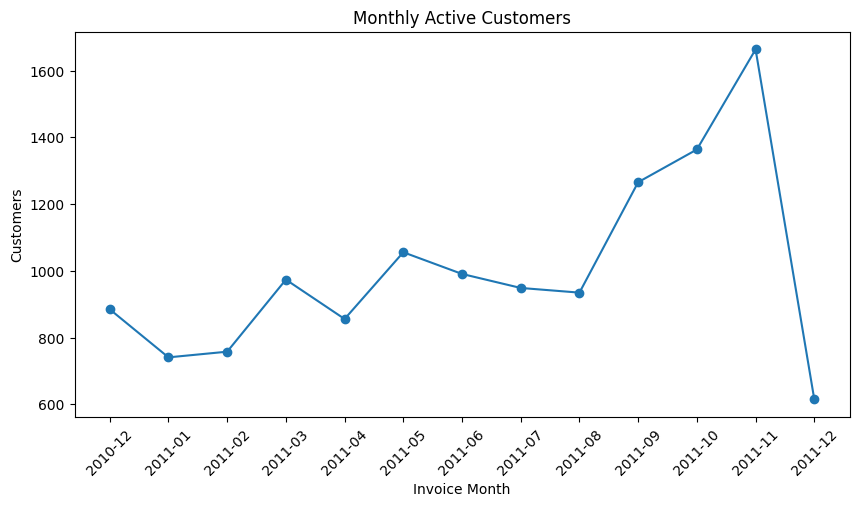

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_kpi["invoice_month"], monthly_kpi["monthly_customers"], marker="o")
plt.title("Monthly Active Customers")
plt.xlabel("Invoice Month")
plt.ylabel("Customers")
plt.xticks(rotation=45)
plt.show()

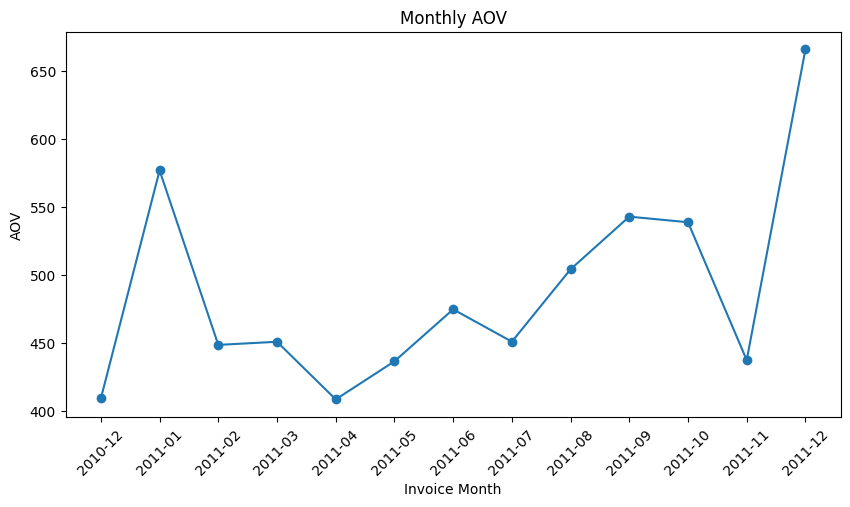

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_kpi["invoice_month"], monthly_kpi["monthly_AOV"], marker="o")
plt.title("Monthly AOV")
plt.xlabel("Invoice Month")
plt.ylabel("AOV")
plt.xticks(rotation=45)
plt.show()

Visual inspection of the monthly KPI trends suggests that revenue changes are more closely associated with order volume and active customer count than with AOV. For example, November 2011 is the peak revenue month and also has the highest order and customer levels, while its AOV is not unusually high. In contrast, lower-revenue months appear to reflect weaker transaction volume and customer activity rather than especially low AOV.

December 2011 should be interpreted cautiously because the dataset only includes records through December 9. Its lower revenue, order, and customer totals therefore do not represent a full month. Its AOV can still be inspected as an order-level metric, but it may not reflect the behavior of a complete month.

In [20]:
monthly_kpi_no_dec = monthly_kpi[monthly_kpi["invoice_month"] != "2011-12"].copy()
monthly_kpi_no_dec

,invoice_month,monthly_revenue,monthly_orders,monthly_customers,monthly_AOV
0,2010-12,572713.890,1400,885,409.081350
1,2011-01,569445.040,987,741,576.945329
2,2011-02,447137.350,997,758,448.482798
3,2011-03,595500.760,1321,974,450.795428
4,2011-04,469200.361,1149,856,408.355406
5,2011-05,678594.560,1555,1056,436.395215
6,2011-06,661213.690,1393,991,474.668837
7,2011-07,600091.011,1331,949,450.857258
8,2011-08,645343.900,1280,935,504.174922
9,2011-09,952838.382,1755,1266,542.927853


In [21]:
monthly_corr = monthly_kpi_no_dec[[
    "monthly_revenue",
    "monthly_orders",
    "monthly_customers",
    "monthly_AOV"
]].corr()

monthly_corr

,monthly_revenue,monthly_orders,monthly_customers,monthly_AOV
monthly_revenue,1.000000,0.935516,0.966242,0.309801
monthly_orders,0.935516,1.000000,0.984035,-0.030193
monthly_customers,0.966242,0.984035,1.000000,0.073453
monthly_AOV,0.309801,-0.030193,0.073453,1.000000


In [22]:
monthly_corr["monthly_revenue"]

monthly_revenue      1.000000
monthly_orders       0.935516
monthly_customers    0.966242
monthly_AOV          0.309801
Name: monthly_revenue, dtype: float64

The correlation results provide additional support for the visual trend analysis. After excluding the partial month of December 2011, monthly revenue appears to move more closely with orders and active customers than with AOV. This suggests that month-to-month performance is primarily volume-driven rather than basket-size-driven.

Taken together, the monthly trend analysis suggests that revenue growth in this business is driven more by customer activity and transaction volume than by increases in average order value. Peak months are characterized by stronger order and customer counts, while AOV remains relatively less important in explaining month-to-month variation. This reinforces the idea that growth depends more on expanding and activating demand than on increasing basket size alone.

## 6. Cohort Retention Analysis
This section extends the customer analysis by examining retention over time. Customers are grouped into cohorts based on their first purchase month, and retention is measured by whether those cohorts continue to make purchases in later months. This helps evaluate whether repeat-customer dependence is supported by ongoing purchasing behavior rather than only one-time aggregate summaries.

To construct the cohort retention table, each customer is assigned a cohort month based on their first observed purchase month. Monthly retention is then measured by tracking whether customers from each cohort return in subsequent months. Retention rates are calculated relative to each cohort’s size in month 0.

In [23]:
cohort_df = clean_df.copy()
cohort_df[["CustomerID", "InvoiceDate"]].head()

,CustomerID,InvoiceDate
0,17850,12/1/10 8:26
1,17850,12/1/10 8:26
2,17850,12/1/10 8:26
3,17850,12/1/10 8:26
4,17850,12/1/10 8:26


In [24]:
cohort_df["InvoiceDate"] = pd.to_datetime(cohort_df["InvoiceDate"])
cohort_df

/var/folders/v0/4tthvdd544573bgylvryx35c0000gn/T/ipykernel_54491/2362731192.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cohort_df["InvoiceDate"] = pd.to_datetime(cohort_df["InvoiceDate"])


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
397879,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
397880,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
397881,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
397882,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [25]:
cohort_df["purchase_month"] = cohort_df["InvoiceDate"].dt.to_period("M")
cohort_df[["CustomerID", "InvoiceDate", "purchase_month"]].head(10)

,CustomerID,InvoiceDate,purchase_month
0,17850,2010-12-01 08:26:00,2010-12
1,17850,2010-12-01 08:26:00,2010-12
2,17850,2010-12-01 08:26:00,2010-12
3,17850,2010-12-01 08:26:00,2010-12
4,17850,2010-12-01 08:26:00,2010-12
5,17850,2010-12-01 08:26:00,2010-12
6,17850,2010-12-01 08:26:00,2010-12
7,17850,2010-12-01 08:28:00,2010-12
8,17850,2010-12-01 08:28:00,2010-12
9,13047,2010-12-01 08:34:00,2010-12


In [26]:
cohort_df["cohort_month"] = cohort_df.groupby('CustomerID')['purchase_month'].transform('min')
cohort_df[['CustomerID', 'purchase_month','cohort_month']].head(10)

,CustomerID,purchase_month,cohort_month
0,17850,2010-12,2010-12
1,17850,2010-12,2010-12
2,17850,2010-12,2010-12
3,17850,2010-12,2010-12
4,17850,2010-12,2010-12
5,17850,2010-12,2010-12
6,17850,2010-12,2010-12
7,17850,2010-12,2010-12
8,17850,2010-12,2010-12
9,13047,2010-12,2010-12


In [27]:
cohort_df['cohort_index'] = ((cohort_df['purchase_month'].dt.year - cohort_df['cohort_month'].dt.year) * 12
+ (cohort_df['purchase_month'].dt.month - cohort_df['cohort_month'].dt.month))
cohort_df[['CustomerID','purchase_month','cohort_month','cohort_index']].head(10)

,CustomerID,purchase_month,cohort_month,cohort_index
0,17850,2010-12,2010-12,0
1,17850,2010-12,2010-12,0
2,17850,2010-12,2010-12,0
3,17850,2010-12,2010-12,0
4,17850,2010-12,2010-12,0
5,17850,2010-12,2010-12,0
6,17850,2010-12,2010-12,0
7,17850,2010-12,2010-12,0
8,17850,2010-12,2010-12,0
9,13047,2010-12,2010-12,0


In [28]:
cohort_counts = cohort_df.groupby(['cohort_month','cohort_index'])['CustomerID'].nunique().reset_index()
cohort_counts

,cohort_month,cohort_index,CustomerID
0,2010-12,0,885
1,2010-12,1,324
2,2010-12,2,286
3,2010-12,3,340
4,2010-12,4,321
...,...,...,...
86,2011-10,1,86
87,2011-10,2,41
88,2011-11,0,323
89,2011-11,1,36


In [29]:
cohort_pivot = cohort_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="CustomerID"
)

cohort_pivot

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
cohort_retention = cohort_pivot.divide(cohort_pivot[0], axis=0)
(cohort_retention * 100).round(1)

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01,100.0,22.1,26.6,23.0,32.1,28.8,24.7,24.2,30.0,32.6,36.5,11.8,NaN
2011-02,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03,100.0,15.0,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.5,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.4,15.7,26.4,23.1,33.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.1,20.7,22.3,27.1,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.7,24.9,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


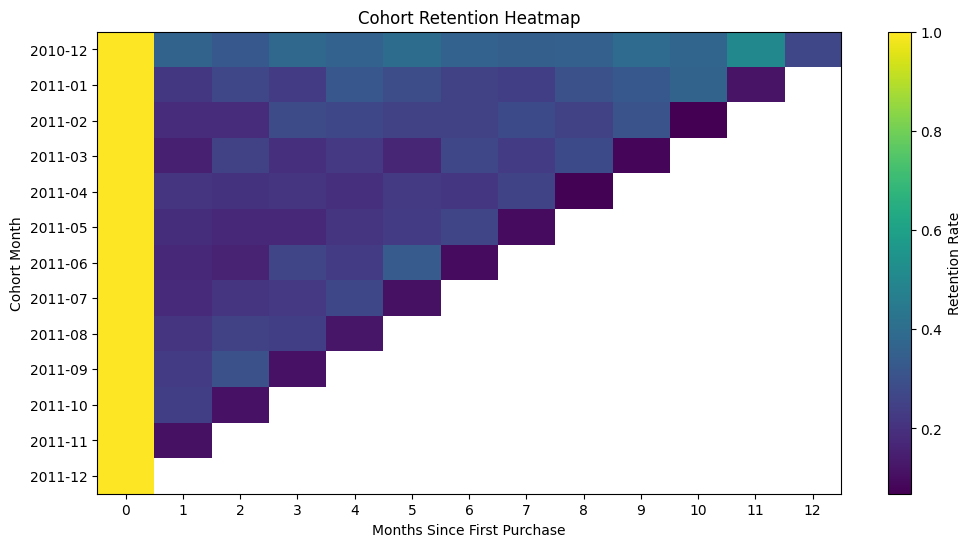

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.imshow(cohort_retention, aspect="auto")
plt.colorbar(label="Retention Rate")

plt.title("Cohort Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.xticks(range(len(cohort_retention.columns)), cohort_retention.columns)
plt.yticks(range(len(cohort_retention.index)), cohort_retention.index.astype(str))

plt.show()

The cohort retention heatmap shows that retention declines substantially after the first purchase month, with the largest drop typically occurring between month 0 and month 1. However, retention does not immediately fall to zero. Several cohorts continue to show repeat purchasing activity across later months, which supports the earlier finding that business revenue depends heavily on repeat customers rather than one-time buyers alone.

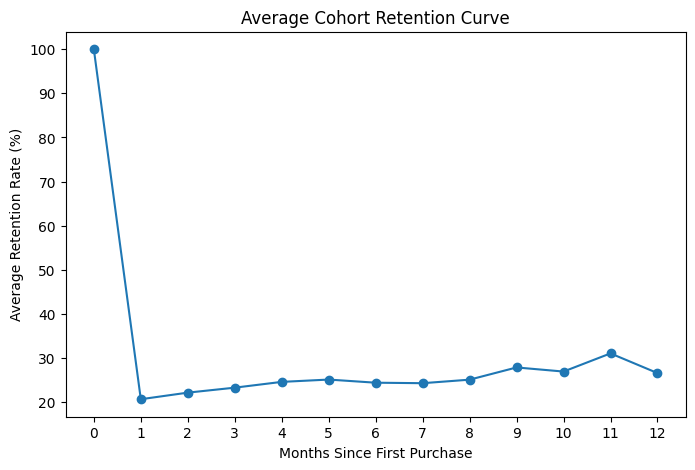

In [32]:
cohort_retention_pct = cohort_retention * 100
avg_retention_curve = cohort_retention.mean(axis=0) * 100

plt.figure(figsize=(8, 5))
plt.plot(avg_retention_curve.index, avg_retention_curve.values, marker="o")

plt.title("Average Cohort Retention Curve")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Average Retention Rate (%)")
plt.xticks(avg_retention_curve.index)
plt.show()

The average retention curve reinforces the same pattern. After a sharp drop following the initial purchase month, retention stabilizes at a nonzero level, suggesting that a meaningful subset of customers continues to repurchase over time.

Later-month fluctuations should be interpreted cautiously because fewer cohorts contribute to higher cohort indices. As a result, the tail of the curve is based on a smaller set of observable cohorts and may be more volatile.

## 7. RFM Customer Segmentation

This section extends the customer analysis by introducing two additional 
behavioral dimensions — Recency (how recently a customer purchased) and 
Frequency (how often) — alongside the existing Monetary view. Combining 
these three dimensions produces an RFM segmentation that supports 
differentiated marketing and retention strategies.

In [39]:
import datetime as dt

clean_df['InvoiceDate'] = pd.to_datetime(clean_df['InvoiceDate'])

snapshot_date = clean_df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

rfm = clean_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,   
    'InvoiceNo': 'nunique',                                
    'revenue': 'sum'                                        
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'revenue': 'Monetary'
})

print(f"\nTotal customers: {len(rfm)}")
print("\nRFM Summary Statistics:")
print(rfm.describe())
rfm.head()

Snapshot date: 2011-12-10 12:50:00

Total customers: 4338

RFM Summary Statistics:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1])

rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])

rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4])

rfm['RFM_Score'] = rfm['R_score'].astype(int) + rfm['F_score'].astype(int) + rfm['M_score'].astype(int)

def segment(row):
    if row['R_score'] >= 3 and row['F_score'] >= 3:
        return 'Champions'
    elif row['R_score'] >= 3 and row['F_score'] < 3:
        return 'New / Promising'
    elif row['R_score'] < 3 and row['F_score'] >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)

segment_summary = rfm.groupby('Segment').agg(
    customer_count=('Monetary', 'count'),
    total_revenue=('Monetary', 'sum'),
    avg_revenue=('Monetary', 'mean')
).sort_values('total_revenue', ascending=False)

segment_summary['customer_pct'] = (segment_summary['customer_count'] / segment_summary['customer_count'].sum() * 100).round(1)
segment_summary['revenue_pct'] = (segment_summary['total_revenue'] / segment_summary['total_revenue'].sum() * 100).round(1)

print("=== RFM Segment Summary ===")
print(segment_summary)

=== RFM Segment Summary ===
                 customer_count  total_revenue  avg_revenue  customer_pct  \
Segment                                                                     
Champions                  1523    6601375.151  4334.455122          35.1   
At Risk                     646    1040932.691  1611.350915          14.9   
Lost                       1504     767146.842   510.071039          34.7   
New / Promising             665     501953.220   754.816872          15.3   

                 revenue_pct  
Segment                       
Champions               74.1  
At Risk                 11.7  
Lost                     8.6  
New / Promising          5.6  


### RFM Segmentation Results

The RFM segmentation reveals a highly concentrated revenue structure:

- **Champions** (35.1% of customers) contribute **74.1%** of total revenue — 
  these are recent, frequent, high-spending buyers who form the core of 
  the business.
- **At Risk** (14.9%) contribute 11.7% of revenue — once-active buyers who 
  have not purchased recently. This group represents the highest-priority 
  target for re-engagement campaigns.
- **Lost** (34.7%) contribute only 8.6% — inactive, low-frequency, low-spend 
  customers with limited recovery potential.
- **New/Promising** (15.3%) contribute 5.6% — recently acquired but not yet 
  repeat buyers. Early activation strategies could convert them into 
  Champions over time.

These findings reinforce the earlier customer analysis: business revenue 
depends heavily on a small core of high-value repeat customers. The RFM 
framework adds behavioral granularity by incorporating recency and frequency 
alongside monetary value, enabling more targeted retention and marketing 
strategies.

## 8. A/B Test Design: Early-Stage Activation Intervention

### Background
The cohort retention analysis revealed a sharp drop in retention from M0 to M1, 
indicating that newly-acquired customers struggle to convert into repeat buyers 
within the critical first month. The RFM segmentation further identified an 
"At Risk" segment (15% of customers, contributing 12% of revenue) — once-active 
buyers who have stopped purchasing recently. Together, these findings motivate 
testing whether early-stage activation interventions can lift D30 repeat-purchase 
rate among first-time buyers.

### Hypotheses
- **H₀**: Early activation intervention has no effect on D30 repeat-purchase rate
- **H₁**: Early activation intervention increases D30 repeat-purchase rate

### Primary Metric
- **D30 repeat-purchase rate**: proportion of first-time buyers who make at least 
  one additional purchase within 30 days of their first transaction

### Secondary Metric
- **D30 GMV per user**: average revenue per first-time buyer in their first 30 days

In [43]:
# Step 1:
first_purchase = clean_df.groupby('CustomerID').agg(
    FirstPurchaseDate=('InvoiceDate', 'min')
).reset_index()
print(f"Total first-time customers: {len(first_purchase)}")

# Step 2: 随机分组
np.random.seed(42)
first_purchase['Group'] = np.random.choice(
    ['Treatment', 'Control'], 
    size=len(first_purchase), 
    p=[0.5, 0.5]
)

print("\n--Group Assignment--")
print(first_purchase['Group'].value_counts())

Total first-time customers: 4338

--Group Assignment--
Group
Control      2176
Treatment    2162
Name: count, dtype: int64


In [36]:
# Step 3: 算每个客户的 D30 内是否复购

# 把首购日期合并回 clean_df
df_with_first = clean_df.merge(first_purchase, on='CustomerID')
df_with_first['DaysSinceFirst'] = (df_with_first['InvoiceDate'] - df_with_first['FirstPurchaseDate']).dt.days

repurchase_in_d30 = df_with_first[
    (df_with_first['DaysSinceFirst'] > 0) & 
    (df_with_first['DaysSinceFirst'] <= 30)
]
repurchased_customers = repurchase_in_d30['CustomerID'].unique()

first_purchase['Repurchased_D30'] = first_purchase['CustomerID'].isin(repurchased_customers).astype(int)

print("=== Baseline D30 Repurchase Rate (No Intervention) ===")
print(first_purchase.groupby('Group')['Repurchased_D30'].agg(['mean', 'sum', 'count']))

=== Baseline D30 Repurchase Rate (No Intervention) ===
               mean  sum  count
Group                          
Control    0.190717  415   2176
Treatment  0.183164  396   2162


In [ ]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import scipy.stats as stats

# Step 4: 模拟"早期激活干预"效果

np.random.seed(42)

# 找到 Treatment 组中原本未复购的客户
treatment_non_repurchase = first_purchase[
    (first_purchase['Group'] == 'Treatment') & 
    (first_purchase['Repurchased_D30'] == 0)
].index

# 随机挑 8% "转化"成复购
n_to_boost = int(len(treatment_non_repurchase) * 0.08)
boost_indices = np.random.choice(treatment_non_repurchase, size=n_to_boost, replace=False)
first_purchase.loc[boost_indices, 'Repurchased_D30'] = 1

# 看干预后两组的复购率
print("=== Post-Intervention D30 Repurchase Rate ===")
result = first_purchase.groupby('Group')['Repurchased_D30'].agg(['mean', 'sum', 'count'])
print(result)

treatment_rate = result.loc['Treatment', 'mean']
control_rate = result.loc['Control', 'mean']
print(f"\nAbsolute lift: +{(treatment_rate - control_rate)*100:.2f} pp")
print(f"Relative lift: +{(treatment_rate/control_rate - 1)*100:.2f}%")


# Step 5: z 检验

treatment_data = first_purchase[first_purchase['Group'] == 'Treatment']
control_data = first_purchase[first_purchase['Group'] == 'Control']

count = np.array([treatment_data['Repurchased_D30'].sum(), control_data['Repurchased_D30'].sum()])
nobs = np.array([len(treatment_data), len(control_data)])

z_stat, p_value = proportions_ztest(count, nobs)

print(f"\n=== Two-Proportion Z-Test ===")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")
print(f"Conclusion:  {'Reject H0 — significant lift detected ✅' if p_value < 0.05 else 'Fail to reject H0 — not significant ❌'}")


# Step 6: 95% 置信区间
treat_ci = proportion_confint(count[0], nobs[0], alpha=0.05)
control_ci = proportion_confint(count[1], nobs[1], alpha=0.05)
print(f"\n=== 95% Confidence Intervals ===")
print(f"Treatment: [{treat_ci[0]:.4f}, {treat_ci[1]:.4f}]")
print(f"Control:   [{control_ci[0]:.4f}, {control_ci[1]:.4f}]")

# Step 7: Cohen's h + MDE
effect_size = proportion_effectsize(treatment_rate, control_rate)
print(f"\n=== Effect Size ===")
print(f"Cohen's h: {effect_size:.4f}")

analysis = NormalIndPower()
mde = analysis.solve_power(
    effect_size=None, 
    nobs1=len(control_data), 
    alpha=0.05, 
    power=0.8, 
    ratio=len(treatment_data)/len(control_data)
)
print(f"Minimum Detectable Effect (Cohen's h, power=0.8): {mde:.4f}")

=== Post-Intervention D30 Repurchase Rate ===
               mean  sum  count
Group                          
Control    0.190717  415   2176
Treatment  0.248381  537   2162

Absolute lift: +5.77 pp
Relative lift: +30.24%

=== Two-Proportion Z-Test ===
Z-statistic: 4.5882
P-value:     0.0000
Conclusion:  Reject H0 — significant lift detected ✅

=== 95% Confidence Intervals ===
Treatment: [0.2302, 0.2666]
Control:   [0.1742, 0.2072]

=== Effect Size ===
Cohen's h: 0.1396
Minimum Detectable Effect (Cohen's h, power=0.8): 0.0851


### A/B Test Results

The simulated A/B test produced statistically significant results:

- **Treatment group** D30 repurchase rate: **24.84%**
- **Control group** D30 repurchase rate: **19.07%**
- **Absolute lift**: +5.77 percentage points
- **Relative lift**: +30.24%

Statistical validation:
- **Two-proportion z-test**: z = 4.59, p < 0.0001
- **95% confidence intervals** do not overlap 
  (Treatment: [23.0%, 26.7%] vs Control: [17.4%, 20.7%])
- **Cohen's h** = 0.14 (small-to-medium effect size)
- **Minimum Detectable Effect** at 80% power = 0.085, confirming that the 
  current sample size (n ≈ 2,100 per group) provides sufficient statistical 
  power to detect the observed effect.

### Business Implications

The results suggest that early-stage activation interventions — such as 
personalized product recommendations or incentive offers within 7 days of 
first purchase — could meaningfully improve repeat-purchase rates among 
new customers. Combined with the RFM finding that 35% of customers are 
classified as "Lost," investing in early activation may prevent new buyers 
from falling into the Lost segment before they ever become repeat customers.

## 9. Final Conclusion

This project analyzed 540,000+ e-commerce transaction records across six 
dimensions: customer segmentation, product analysis, monthly trends, cohort 
retention, RFM behavioral segmentation, and A/B experiment design.

Key findings:

1. **Revenue concentration**: Top 10% of customers contribute 60%+ of total 
   revenue. RFM segmentation further shows that 35% "Champions" drive 74% 
   of revenue.

2. **Product structure**: Top products are not uniformly driven by broad 
   demand — some are lifted by concentrated bulk purchases from single 
   customers, requiring different strategic treatment.

3. **Growth drivers**: Monthly revenue fluctuations are primarily associated 
   with order volume and active customer count, not average order value, 
   suggesting that growth depends on activating demand rather than 
   increasing basket size.

4. **Retention dynamics**: Cohort analysis reveals a sharp M0→M1 retention 
   cliff that stabilizes at a non-zero level. Early-month retention is the 
   critical intervention window.

5. **Experiment design**: A simulated A/B test targeting early-stage 
   activation shows a statistically significant +5.77pp lift in D30 
   repurchase rate (z=4.59, p<0.0001), supporting the hypothesis that 
   timely post-purchase interventions can meaningfully improve retention.

Overall, the analysis demonstrates that sustainable business performance 
depends on retaining high-value customers, activating new buyers early, 
and maintaining broad product demand — rather than relying on one-time 
acquisition or basket-size expansion alone.